# Linear Regression from Scratch

In [6]:
import numpy as np
import matplotlib.pyplot as plt


In [7]:

def predict(X, weights, bias):
    """
    Calculates the predicted values based on the linear equation 
    y_hat = X * weights + bias
    """

    return np.dot(X,weights) + bias

def compute_cost(y_predicted, y_actual):

    """ 
    Calculate the MSE cost
    """

    m = len(y_actual)
    return (1/(2*m)*(np.sum((y_predicted-y_actual)**2)))

def gradient_descent(X, y, learning_rate, n_iterations):
    """
    Find optimal weights and bias via gradient descent
    """
    m,n = X.shape

    weights = np.zeros(n) #initializes weights to zeros
    bias = 0.0              #init bias to zero
    cost_history = []

    for i in range(n_iterations):
        # Make prediction
        y_predicted = predict(X, weights, bias)

        #2. Calculate the gradients (Partial Derivates of cost function)
        errors = y_predicted - y

        dw = (1/m) * np.dot(X.T, errors) # gradient for the weights
        db = (1/m) * np.sum(errors)  # Gradient for bias

        # 3. update weights andd bias

        weights -= learning_rate * dw
        biaas -= learning_rate * db

        # 4. store cost
        cost = compute_cost(y_predicted, y)
        cost_history.append(cost)

    return weights, bias, cost_history











In [30]:
# 1. Generate some synthetic data

np.random.seed(0)
X = 2 * np.random.rand(100,1) # a single feature
y = (4 + 3 * X + np.random.randn(100,1)).flatten()

# 2. Set Hyperparameters
learning_rate = 0.004
n_iterations = 1000

# 3. Run the training function
final_weights, final_bias, cost_history = gradient_descent(X, y, learning_rate, n_iterations)

print(f"Final Weights: {final_weights[0]:.4f}, Final Bias: {final_bias:.4f}")

--- Training with Gradient Descent ---
Iteration    0: Cost  26.6652
Iteration  150: Cost   2.7521
Iteration  300: Cost   0.7528
Iteration  450: Cost   0.5747
Iteration  600: Cost   0.5499
Iteration  750: Cost   0.5395
Iteration  900: Cost   0.5319
Iteration  999: Cost   0.5276
Final Weights: 3.3816, Final Bias: 3.7547


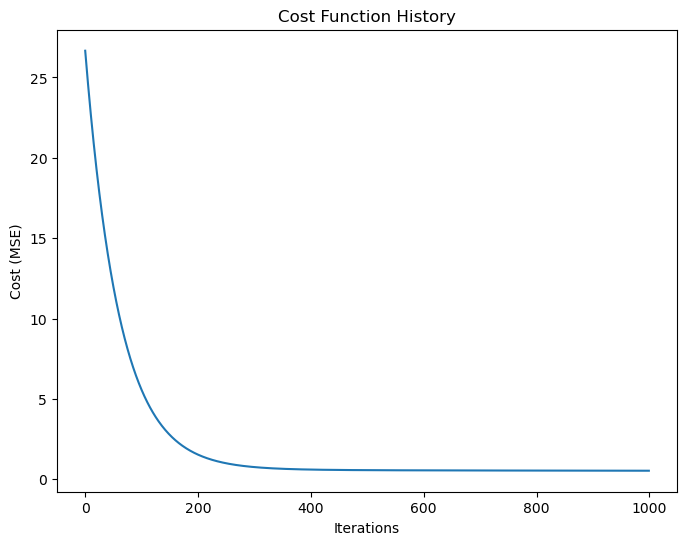

In [31]:


# 4. Plot the cost history to show convergence
plt.figure(figsize=(8, 6))
plt.plot(cost_history)
plt.title('Cost Function History')
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.show()

In [32]:
# 5. Make a final prediction on a new data point
new_X = np.array([[2]])
predicted_y = predict(new_X, final_weights, final_bias)
print(f"Predicted y for X={new_X[0][0]}: {predicted_y[0]:.4f}")

Predicted y for X=2: 10.5179


--- Training with Gradient Descent ---
Iteration    0: Cost 1570.6230
Iteration  150: Cost  16.9612
Iteration  300: Cost  16.5893
Iteration  450: Cost  16.2332
Iteration  600: Cost  15.8921
Iteration  750: Cost  15.5654
Iteration  900: Cost  15.2526
Iteration  999: Cost  15.0534

Final Learned Weights: 3.4767
Final Learned Bias: 1.7240


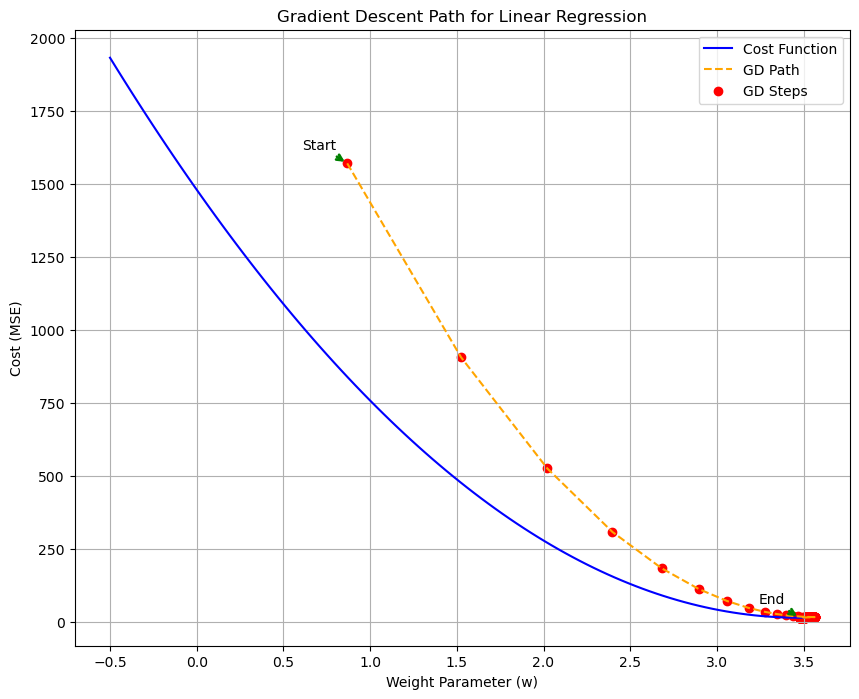

In [51]:
import numpy as np
import matplotlib.pyplot as plt

def predict(X, weights, bias):
    """
    Calculates the predicted values based on the linear model equation.
    y_hat = X * weights + bias

    Args:
        X (np.ndarray): Input features (e.g., city population).
        weights (np.ndarray): Model weights.
        bias (float): Model bias.

    Returns:
        np.ndarray: Predicted target values (e.g., restaurant profits).
    """
    return np.dot(X, weights) + bias

def compute_cost(y_predicted, y_actual):
    """
    Calculates the Mean Squared Error (MSE) cost.

    Args:
        y_predicted (np.ndarray): Predicted values.
        y_actual (np.ndarray): True target values.

    Returns:
        float: The MSE cost.
    """
    m = len(y_actual)
    return (1 / (2 * m)) * np.sum((y_predicted - y_actual)**2)

def gradient_descent(X, y, learning_rate, n_iterations):
    """
    Performs gradient descent to find the optimal weights and bias.
    This version also tracks the history of weights for visualization.

    Args:
        X (np.ndarray): Training features.
        y (np.ndarray): Target values.
        learning_rate (float): The step size for gradient descent.
        n_iterations (int): The number of training iterations.

    Returns:
        tuple: (final_weights, final_bias, cost_history, weights_history)
               - final_weights (np.ndarray): Learned weights.
               - final_bias (float): Learned bias.
               - cost_history (list): MSE cost at each iteration.
               - weights_history (list): The value of the weights at each iteration.
    """
    m, n = X.shape
    weights = np.zeros(n)  # Initialize weights to zeros
    bias = 0.0             # Initialize bias to zero
    cost_history = []
    weights_history = []

    print("--- Training with Gradient Descent ---")
    for i in range(n_iterations):
        # 1. Make predictions
        y_predicted = predict(X, weights, bias)

        # 2. Calculate the gradients
        errors = y_predicted - y
        dw = (1 / m) * np.dot(X.T, errors)  # Gradient for weights
        db = (1 / m) * np.sum(errors)      # Gradient for bias

        # 3. Update the weights and bias
        weights -= learning_rate * dw
        bias -= learning_rate * db

        # 4. Store and print the cost and weights
        cost = compute_cost(y_predicted, y)
        cost_history.append(cost)
        weights_history.append(weights[0])

        # Print progress every 150 iterations as requested
        if (i % 150 == 0) or (i == n_iterations - 1):
            print(f"Iteration {i:4d}: Cost {cost:8.4f}")

    return weights, bias, cost_history, weights_history

# --- Putting it all together ---
# 1. Generate some synthetic data for City Population vs. Restaurant Profits
np.random.seed(42)
# City population in 10,000s
X_train = 2 * np.random.rand(100, 1) * 10 + 5 
# Restaurant profits in $10,000s. The underlying relationship is y = 1.5*x + 2 + noise
y_train = 4 + 3 * (X_train + 2 + np.random.randn(100, 1) * 1.5).flatten()

# 2. Set hyperparameters
learning_rate = 0.001
n_iterations = 1000

# 3. Run the training function
final_weights, final_bias, cost_history, weights_history = gradient_descent(X_train, y_train, learning_rate, n_iterations)

print(f"\nFinal Learned Weights: {final_weights[0]:.4f}")
print(f"Final Learned Bias: {final_bias:.4f}")

# --- New Plotting Section for Gradient Descent Visualization ---
plt.figure(figsize=(10, 8))

# Define a range of possible weights to plot the cost function's curve
w_values = np.linspace(-0.5, 3.5, 100)
cost_curve = [compute_cost(predict(X_train, np.array([w]), final_bias), y_train) for w in w_values]

# Plot the cost function curve
plt.plot(w_values, cost_curve, c="b", label='Cost Function')

# Plot the path of gradient descent steps
plt.plot(weights_history, cost_history, c="orange", linestyle='--', label='GD Path')
plt.scatter(weights_history, cost_history, c="r", marker='o', label='GD Steps')

# Add annotations for start and end
plt.annotate('Start', (weights_history[0], cost_history[0]), textcoords="offset points", xytext=(-20,10), ha='center', arrowprops=dict(arrowstyle="->", color='green', lw=2))
plt.annotate('End', (weights_history[-1], cost_history[-1]), textcoords="offset points", xytext=(-20,10), ha='center', arrowprops=dict(arrowstyle="->", color='green', lw=2))

# Set the title and labels
plt.title("Gradient Descent Path for Linear Regression")
plt.xlabel('Weight Parameter (w)')
plt.ylabel('Cost (MSE)')
plt.legend()
plt.grid(True)
plt.show()